## Folder Structure for Dataset

```
data/
├── raw/                     # Original images (before split)
│   └── [person_name]/
├── train_raw/               # Training split (raw images)
│   └── [person_name]/
├── test_raw/                # Test split (raw images)
│   └── [person_name]/
├── converted/               # Standardized JPG images (train only)
│   └── [person_name]/
├── preprocessed/            # Grayscale + CLAHE processed (train only)
│   └── [person_name]/
├── faces_detected/          # Extracted face ROIs 128x128 (train only)
│   └── [person_name]/
├── final_processed/         # Post-processed face ROIs (train only)
│   └── [person_name]/
├── test_processed/          # Post-processed face ROIs from test_raw (test only)
│   └── [person_name]/
├── augmented/               # Augmented face crops (train only)
│   └── [person_name]/
└── preview/                 # Preview & evaluation results
    ├── augmentation_samples/
    └── evaluation_results/
models/
├── lbph_model.yml           # Trained LBPH face recognizer
└── label_map.txt            # Person name → label ID mapping
```

In [15]:
# Import all required libraries
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import face_recognition
import time
import random
from pathlib import Path
from PIL import Image, ImageEnhance, ImageOps
import shutil
import tempfile
import dlib

# For HEIC conversion
try:
    from pillow_heif import register_heif_opener
    register_heif_opener()
    HAS_HEIF_SUPPORT = True
    print("✅ HEIC support available")
except ImportError:
    HAS_HEIF_SUPPORT = False
    print("⚠️  HEIC support not available. Install pillow-heif if needed.")

# For advanced augmentation
try:
    import albumentations as A
    HAS_ALBUMENTATIONS = True
    print("✅ Advanced augmentation available")
except ImportError:
    HAS_ALBUMENTATIONS = False
    print("⚠️  Advanced augmentation not available. Install albumentations if needed.")

try:
    import dlib
    print("✅ dlib support available")
except ImportError:
    print("⚠️  dlib support not available. Install dlib if needed.")

print("📦 Core libraries loaded successfully!")

✅ HEIC support available
✅ Advanced augmentation available
✅ dlib support available
📦 Core libraries loaded successfully!


# Configuration Settings


In [16]:
# === CONFIGURATION SETTINGS ===

# File paths
DATA_FOLDER = os.path.join("..", "data")
RAW_FOLDER = os.path.join(DATA_FOLDER, "raw")
TRAIN_RAW_FOLDER = os.path.join(DATA_FOLDER, "train_raw")
TEST_RAW_FOLDER = os.path.join(DATA_FOLDER, "test_raw")
TEST_PROCESSED_FOLDER = os.path.join(DATA_FOLDER, "test_processed")
PREVIEW_FOLDER = os.path.join(DATA_FOLDER, "preview")

# Processing folders (train only - after train/test split)
CONVERTED_FOLDER = os.path.join(DATA_FOLDER, "converted")
PREPROCESSED_FOLDER = os.path.join(DATA_FOLDER, "preprocessed")
FACES_DETECTED_FOLDER = os.path.join(DATA_FOLDER, "faces_detected")
FINAL_PROCESSED_FOLDER = os.path.join(DATA_FOLDER, "final_processed")
AUGMENTED_FOLDER = os.path.join(DATA_FOLDER, "augmented")

# Models folder 
MODELS_FOLDER = os.path.join("..", "models")

# Preprocessing settings
FACE_PADDING_RATIO = 0.2  # 20% padding around detected faces
OUTPUT_SIZE = (128, 128)  # Final size for preprocessed face images
CLAHE_CLIP_LIMIT = 2.0  # CLAHE clip limit for contrast enhancement
CLAHE_GRID_SIZE = (8, 8)  # CLAHE grid size for local enhancement
BLUR_THRESHOLD = 20      # Laplacian variance threshold, used for monitoring only

# Detection settings
DETECTION_SCALE_FACTOR = 0.25  # Scale factor for faster detection (1/4 size)
DETECTION_MODEL = "hog"  # Face detection model: 'hog' for speed, 'cnn' for accuracy

# Image conversion settings
IMAGE_QUALITY = 95  # JPG quality 
MAX_IMAGE_SIZE = (1024, 1024)  # Max size for converted images

# Display settings
PREVIEW_GRID_COLS = 4  # Columns in preview grids
FIGURE_SIZE = (15, 10)  # Default matplotlib figure size

In [17]:
# === CREATE DATASET FOLDERS ===
# Sync person folders from data/raw so people is always exactly the same as raw.

print("Creating full dataset folder structure...")
print("=" * 55)

# Top-level folders
top_level_folders = [
    DATA_FOLDER,
    RAW_FOLDER,
    TRAIN_RAW_FOLDER,
    TEST_RAW_FOLDER,
    TEST_PROCESSED_FOLDER,
    PREVIEW_FOLDER,
    MODELS_FOLDER,
]
for folder in top_level_folders:
    os.makedirs(folder, exist_ok=True)

# Processing stage folders (train only - created after train/test split)
processing_stage_folders = [
    CONVERTED_FOLDER,
    PREPROCESSED_FOLDER,
    FACES_DETECTED_FOLDER,
    FINAL_PROCESSED_FOLDER,
    AUGMENTED_FOLDER,
]
for folder in processing_stage_folders:
    os.makedirs(folder, exist_ok=True)

# Read people directly from raw folder (single source of truth)
people = sorted([
    person for person in os.listdir(RAW_FOLDER)
    if os.path.isdir(os.path.join(RAW_FOLDER, person))
])

if not people:
    print(f"⚠️ No person folders found in {RAW_FOLDER}")
    print("   Add person folders to data/raw first, then re-run this cell.")
else:
    print(f"📁 Synced people from raw: {len(people)}")

    # Create person subfolders in train_raw and test_raw (after split)
    for person in people:
        os.makedirs(os.path.join(TRAIN_RAW_FOLDER, person), exist_ok=True)
        os.makedirs(os.path.join(TEST_RAW_FOLDER, person), exist_ok=True)
        os.makedirs(os.path.join(TEST_PROCESSED_FOLDER, person), exist_ok=True)

    # Create person subfolders in processing stages (train only)
    for person in people:
        for base in processing_stage_folders:
            os.makedirs(os.path.join(base, person), exist_ok=True)

# Preview subfolders used by later visualization/evaluation cells
preview_subfolders = [
    os.path.join(PREVIEW_FOLDER, "augmentation_samples"),
    os.path.join(PREVIEW_FOLDER, "evaluation_results"),
]
for folder in preview_subfolders:
    os.makedirs(folder, exist_ok=True)


Creating full dataset folder structure...
📁 Synced people from raw: 21


# Dataset Analysis

In [18]:
def analyze_dataset():
    """Analyze the current raw dataset structure and contents."""

    if not os.path.exists(RAW_FOLDER):
        print(f"❌ Raw folder not found: {RAW_FOLDER}")
        return False

    print("🔍 DATASET ANALYSIS")
    print("=" * 50)

    person_dirs = [f for f in os.listdir(RAW_FOLDER)
                   if os.path.isdir(os.path.join(RAW_FOLDER, f))]

    if not person_dirs:
        print(f"❌ No person folders found in {RAW_FOLDER}")
        print("   Create a subfolder per person and add their photos.")
        return False

    total_images = 0
    format_stats = {}
    person_stats = {}

    print(f"📁 Found {len(person_dirs)} people in data/raw/:\n")

    for person in sorted(person_dirs):
        person_path = os.path.join(RAW_FOLDER, person)
        image_files = [f for f in os.listdir(person_path)
                       if os.path.isfile(os.path.join(person_path, f)) and
                       Path(f).suffix.lower() in {'.jpg', '.jpeg', '.png', '.heic'}]

        person_stats[person] = len(image_files)
        total_images += len(image_files)

        for img in image_files:
            ext = Path(img).suffix.lower()
            format_stats[ext] = format_stats.get(ext, 0) + 1

        flag = "✅" if len(image_files) >= 5 else ("⚠️" if len(image_files) > 0 else "❌")
        print(f"  {flag} {person}: {len(image_files)} images")

    print(f"\n📊 SUMMARY:")
    print(f"  • Total people:        {len(person_dirs)}")
    print(f"  • Total images:        {total_images}")
    if person_dirs:
        print(f"  • Avg per person:      {total_images / len(person_dirs):.1f}")
        min_person = min(person_stats, key=person_stats.get)
        max_person = max(person_stats, key=person_stats.get)
        print(f"  • Min: {person_stats[min_person]} ({min_person})")
        print(f"  • Max: {person_stats[max_person]} ({max_person})")

    print(f"\n📂 PROCESSING FOLDERS STATUS:")
    pipeline_folders = [
        ('converted',       CONVERTED_FOLDER),
        ('preprocessed',    PREPROCESSED_FOLDER),
        ('final_processed', FINAL_PROCESSED_FOLDER),
        ('test_processed',  TEST_PROCESSED_FOLDER),
        ('augmented',       AUGMENTED_FOLDER),
    ]
    for name, path in pipeline_folders:
        if os.path.exists(path):
            count = sum(
                len([f for f in os.listdir(os.path.join(path, p))
                     if Path(f).suffix.lower() in {'.jpg', '.jpeg', '.png'}])
                for p in os.listdir(path)
                if os.path.isdir(os.path.join(path, p))
            )
            print(f"  ✅ {name}: {count} files")
        else:
            print(f"  ❌ {name}: not created yet")

    people_with_few = [p for p, c in person_stats.items() if c < 5]
    if people_with_few:
        print(f"\n⚠️  People with fewer than 5 images (add more photos):")
        for p in people_with_few:
            print(f"     • {p}: {person_stats[p]} image(s)")

    return True

# Run the analysis
analyze_dataset()


🔍 DATASET ANALYSIS
📁 Found 21 people in data/raw/:

  ✅ Dr.Nurul: 11 images
  ✅ benjamin: 41 images
  ✅ chern_tak: 36 images
  ✅ chillien: 14 images
  ✅ daniel: 54 images
  ✅ dylan: 40 images
  ✅ han_soon: 11 images
  ✅ harry: 23 images
  ✅ isaac: 10 images
  ✅ jing_ang: 9 images
  ✅ jun_wei: 9 images
  ✅ kang_kai: 16 images
  ✅ marion: 11 images
  ✅ qi_xuan: 11 images
  ✅ shuang_quan: 56 images
  ✅ wee_xuan: 16 images
  ✅ xiang_yue: 14 images
  ✅ xu_sheng: 23 images
  ✅ yoke_hong: 49 images
  ✅ yong_kang: 13 images
  ✅ zi_herng: 11 images

📊 SUMMARY:
  • Total people:        21
  • Total images:        478
  • Avg per person:      22.8
  • Min: 9 (jing_ang)
  • Max: 56 (shuang_quan)

📂 PROCESSING FOLDERS STATUS:
  ✅ converted: 335 files
  ✅ preprocessed: 335 files
  ✅ final_processed: 215 files
  ✅ test_processed: 94 files
  ✅ augmented: 0 files


True

# Step 1: Image Conversion, Standardization & Train/Test Split

In [19]:
def convert_heic_to_jpg(input_path, output_path, quality=95):
    """Convert HEIC file to JPG"""
    if not HAS_HEIF_SUPPORT:
        print(f"⚠️ HEIC support not available. Skipping {input_path}")
        return False

    try:
        with Image.open(input_path) as image:
            if image.mode != 'RGB':
                image = image.convert('RGB')
            image.save(output_path, 'JPEG', quality=quality, optimize=True)
            return True
    except Exception as e:
        print(f"❌ Error converting {input_path}: {e}")
        return False


def standardize_image(input_path, output_path, target_size=MAX_IMAGE_SIZE, quality=IMAGE_QUALITY):
    """Standardize image size and format"""
    try:
        with Image.open(input_path) as image:
            if image.mode != 'RGB':
                image = image.convert('RGB')
            image = ImageOps.fit(image, target_size, Image.Resampling.LANCZOS)
            image.save(output_path, 'JPEG', quality=quality, optimize=True)
            return True
    except Exception as e:
        print(f"❌ Error standardizing {input_path}: {e}")
        return False


def convert_all_images(test_ratio=0.3, random_seed=42):
    """Standardize all images and split train/test without Step-1 per-person cap."""

    print("🔄 STARTING IMAGE CONVERSION + SPLIT")
    print("=" * 72)

    required_folders = [RAW_FOLDER, CONVERTED_FOLDER, TRAIN_RAW_FOLDER, TEST_RAW_FOLDER]
    for folder in required_folders:
        if not os.path.exists(folder):
            print(f"❌ Required folder not found: {folder}")
            return 0, 0, 0, 0

    person_dirs = [
        f for f in os.listdir(RAW_FOLDER)
        if os.path.isdir(os.path.join(RAW_FOLDER, f))
    ]
    if not person_dirs:
        print(f"❌ No person folders found in {RAW_FOLDER}")
        return 0, 0, 0, 0

    total_converted = 0
    total_failed = 0
    total_train = 0
    total_test = 0

    image_extensions = {'.jpg', '.jpeg', '.png', '.heic', '.JPG', '.JPEG', '.PNG', '.HEIC'}

    for person_idx, person in enumerate(sorted(person_dirs)):
        person_input_path = os.path.join(RAW_FOLDER, person)
        person_converted_path = os.path.join(CONVERTED_FOLDER, person)
        person_train_raw_path = os.path.join(TRAIN_RAW_FOLDER, person)
        person_test_raw_path = os.path.join(TEST_RAW_FOLDER, person)

        os.makedirs(person_converted_path, exist_ok=True)
        os.makedirs(person_train_raw_path, exist_ok=True)
        os.makedirs(person_test_raw_path, exist_ok=True)

        for out_folder in [person_converted_path, person_train_raw_path, person_test_raw_path]:
            old_files = [
                f for f in os.listdir(out_folder)
                if os.path.isfile(os.path.join(out_folder, f)) and Path(f).suffix in image_extensions
            ]
            for old_file in old_files:
                os.remove(os.path.join(out_folder, old_file))

        image_files = [
            f for f in os.listdir(person_input_path)
            if os.path.isfile(os.path.join(person_input_path, f)) and Path(f).suffix in image_extensions
        ]

        if not image_files:
            print(f"\n👤 {person}: no images found, skipped")
            continue

        print(f"\n👤 Processing {person} ({len(image_files)} raw images):")

        standardized_pool = []
        with tempfile.TemporaryDirectory() as temp_dir:
            # 1) Standardize first.
            for filename in sorted(image_files):
                input_file = os.path.join(person_input_path, filename)
                temp_output = os.path.join(temp_dir, f"{Path(filename).stem}_std.jpg")
                is_heic = Path(filename).suffix.lower() == '.heic'

                if is_heic:
                    success = convert_heic_to_jpg(input_file, temp_output, IMAGE_QUALITY)
                    if success and os.path.exists(temp_output):
                        success = standardize_image(temp_output, temp_output)
                else:
                    success = standardize_image(input_file, temp_output)

                if success and os.path.exists(temp_output):
                    standardized_pool.append((filename, temp_output))
                else:
                    print(f"  ❌ Failed (standardize): {filename}")
                    total_failed += 1

            if not standardized_pool:
                print("  ⚠️ No valid standardized images.")
                continue

            # 2) Split into train/test.
            rng = np.random.RandomState(random_seed + person_idx)
            rng.shuffle(standardized_pool)

            if len(standardized_pool) == 1:
                test_count = 0
            else:
                test_count = max(1, int(round(len(standardized_pool) * test_ratio)))
                test_count = min(test_count, len(standardized_pool) - 1)

            test_items = standardized_pool[:test_count]
            train_items = standardized_pool[test_count:]

            # Save standardized JPG test outputs.
            test_index = 1
            for raw_filename, standardized_file in test_items:
                test_output_filename = f"{person}_test_{test_index:03d}.jpg"
                shutil.copy2(
                    standardized_file,
                    os.path.join(person_test_raw_path, test_output_filename),
                )
                test_index += 1
                total_test += 1
                print(f"  🧪 TEST  {raw_filename} → {test_output_filename}")

            if not train_items:
                print(f"  ⚠️ No train images left after split.")
                print(f"  📊 {person} final split: train=0, test={len(test_items)}")
                continue

            # No cap here: keep all train items.
            final_train_items = train_items
            print(f"  🎯 Train kept: {len(final_train_items)}")

            # Save train_raw + converted from train selection.
            converted_index = 1
            for raw_filename, standardized_file in final_train_items:
                shutil.copy2(
                    os.path.join(person_input_path, raw_filename),
                    os.path.join(person_train_raw_path, raw_filename),
                )
                total_train += 1

                output_filename = f"{person}_{converted_index:03d}.jpg"
                output_file = os.path.join(person_converted_path, output_filename)
                shutil.copy2(standardized_file, output_file)
                converted_index += 1
                total_converted += 1
                print(f"  ✅ TRAIN {raw_filename} → {output_filename}")

            print(f"  📊 {person} final split: train={len(final_train_items)}, test={len(test_items)}")

    print(f"\n✨ CONVERSION + SPLIT COMPLETE!")
    print(f"  ✅ Converted train images: {total_converted}")
    print(f"  🏋️ Train raw images:       {total_train}")
    print(f"  🧪 Test raw images:        {total_test}")
    print(f"  ❌ Failed:                 {total_failed}")
    print(f"  📁 Converted (train): {CONVERTED_FOLDER}")
    print(f"  📁 Train raw:         {TRAIN_RAW_FOLDER}")
    print(f"  📁 Test raw:          {TEST_RAW_FOLDER}")

    return total_converted, total_train, total_test, total_failed


conversionAndSplitConversion_stats = convert_all_images(test_ratio=0.3, random_seed=42)

🔄 STARTING IMAGE CONVERSION + SPLIT

👤 Processing Dr.Nurul (11 raw images):
  🧪 TEST  IMG_5228.HEIC → Dr.Nurul_test_001.jpg
  🧪 TEST  IMG_5222.HEIC → Dr.Nurul_test_002.jpg
  🧪 TEST  IMG_5232.HEIC → Dr.Nurul_test_003.jpg
  🎯 Train kept: 8
  ✅ TRAIN IMG_5233.HEIC → Dr.Nurul_001.jpg
  ✅ TRAIN IMG_5225.HEIC → Dr.Nurul_002.jpg
  ✅ TRAIN IMG_5223.HEIC → Dr.Nurul_003.jpg
  ✅ TRAIN IMG_5231.HEIC → Dr.Nurul_004.jpg
  ✅ TRAIN IMG_5227.HEIC → Dr.Nurul_005.jpg
  ✅ TRAIN IMG_5230.HEIC → Dr.Nurul_006.jpg
  ✅ TRAIN IMG_5226.HEIC → Dr.Nurul_007.jpg
  ✅ TRAIN IMG_5229.HEIC → Dr.Nurul_008.jpg
  📊 Dr.Nurul final split: train=8, test=3

👤 Processing benjamin (41 raw images):
  🧪 TEST  IMG_5272.HEIC → benjamin_test_001.jpg
  🧪 TEST  IMG_1931.JPG → benjamin_test_002.jpg
  🧪 TEST  IMG_5278.HEIC → benjamin_test_003.jpg
  🧪 TEST  IMG_5284.HEIC → benjamin_test_004.jpg
  🧪 TEST  IMG_1932.JPG → benjamin_test_005.jpg
  🧪 TEST  IMG_5282.HEIC → benjamin_test_006.jpg
  🧪 TEST  IMG_1933.JPG → benjamin_test_007.jpg
  🧪

# Step 2: Grayscale & CLAHE Preprocessing

Apply grayscale conversion and CLAHE enhancement to all converted images for better face detection:

In [20]:
class ImagePreprocessor:
    def __init__(self, clahe_clip_limit=CLAHE_CLIP_LIMIT, clahe_grid_size=CLAHE_GRID_SIZE):
        """Initialize preprocessor with CLAHE settings"""
        self.clahe = cv2.createCLAHE(clipLimit=clahe_clip_limit, tileGridSize=clahe_grid_size)
        print(f"✅ Image preprocessor initialized")
        print(f"   • CLAHE clip limit: {clahe_clip_limit}")
        print(f"   • CLAHE grid size: {clahe_grid_size}")
    
    def preprocess_image(self, image):
        """Apply CLAHE enhancement on grayscale image"""
        if len(image.shape) == 3:
            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        else:
            gray = image
        
        enhanced = self.clahe.apply(gray)
        return enhanced
    
    def preprocess_folder(self, input_folder, output_folder):
        """Process all images in a folder and save CLAHE-only outputs"""
        # Verify folders exist
        if not os.path.exists(input_folder):
            print(f"❌ Input folder not found: {input_folder}")
            return 0, 0
        
        if not os.path.exists(output_folder):
            print(f"❌ Output folder not found: {output_folder}")
            return 0, 0
        
        # Get person folders
        person_folders = [f for f in os.listdir(input_folder) 
                         if os.path.isdir(os.path.join(input_folder, f))]
        
        total_processed = 0
        total_failed = 0
        
        for person in person_folders:
            person_input_path = os.path.join(input_folder, person)
            person_output_path = os.path.join(output_folder, person)
            if not os.path.exists(person_output_path):
                os.makedirs(person_output_path, exist_ok=True)

            old_outputs = [f for f in os.listdir(person_output_path)
                           if Path(f).suffix.lower() in {'.jpg', '.jpeg', '.png'}]
            for old_file in old_outputs:
                os.remove(os.path.join(person_output_path, old_file))
            if old_outputs:
                print(f"Cleared {len(old_outputs)} old preprocessed file(s) for {person}")
            
            # Get image files
            image_files = [f for f in os.listdir(person_input_path) if f.lower().endswith('.jpg')]
            
            # Skip folders with no images — don't create empty output dirs
            if not image_files:
                print(f"  ⚠️ No images found for {person} — skipped")
                continue
            
            print(f"\n👤 Preprocessing {person} ({len(image_files)} images):")
            
            for image_file in image_files:
                input_path = os.path.join(person_input_path, image_file)
                image = cv2.imread(input_path)
                
                if image is None:
                    print(f"  ❌ Failed to read: {image_file}")
                    total_failed += 1
                    continue
                
                # Apply preprocessing (CLAHE only)
                enhanced = self.preprocess_image(image)
                
                # Save CLAHE version only
                base_name = Path(image_file).stem
                enhanced_path = os.path.join(person_output_path, f"{base_name}_clahe.jpg")
                cv2.imwrite(enhanced_path, enhanced)
                
                total_processed += 1
                print(f"  ✅ {image_file} → CLAHE version")
        
        print(f"\n✨ PREPROCESSING COMPLETE!")
        print(f"  ✅ Processed: {total_processed}")
        print(f"  ❌ Failed: {total_failed}")
        print(f"  📁 Output: {output_folder}")
        
        return total_processed, total_failed

# Initialize preprocessor
preprocessor = ImagePreprocessor()
print("🔄 Image preprocessor ready!")

✅ Image preprocessor initialized
   • CLAHE clip limit: 2.0
   • CLAHE grid size: (8, 8)
🔄 Image preprocessor ready!


In [21]:
def run_preprocessing():
    """Apply grayscale + CLAHE preprocessing to converted images"""
    print("🔄 STARTING PREPROCESSING")  
    print("=" * 50)
    
    if not os.path.exists(CONVERTED_FOLDER):
        print("❌ Converted folder not found! Please run image conversion first.")
        return
    
    # Run preprocessing
    stats = preprocessor.preprocess_folder(CONVERTED_FOLDER, PREPROCESSED_FOLDER)
    
    print("\n📊 PREPROCESSING SUMMARY:")
    print(f"Images processed: {stats[0]}")
    print(f"Failed: {stats[1]}")
    print(f"📁 Output: {PREPROCESSED_FOLDER}")
    
    return stats

# Run preprocessing
preprocessing_stats = run_preprocessing()

🔄 STARTING PREPROCESSING
Cleared 29 old preprocessed file(s) for benjamin

👤 Preprocessing benjamin (29 images):
  ✅ benjamin_001.jpg → CLAHE version
  ✅ benjamin_002.jpg → CLAHE version
  ✅ benjamin_003.jpg → CLAHE version
  ✅ benjamin_004.jpg → CLAHE version
  ✅ benjamin_005.jpg → CLAHE version
  ✅ benjamin_006.jpg → CLAHE version
  ✅ benjamin_007.jpg → CLAHE version
  ✅ benjamin_008.jpg → CLAHE version
  ✅ benjamin_009.jpg → CLAHE version
  ✅ benjamin_010.jpg → CLAHE version
  ✅ benjamin_011.jpg → CLAHE version
  ✅ benjamin_012.jpg → CLAHE version
  ✅ benjamin_013.jpg → CLAHE version
  ✅ benjamin_014.jpg → CLAHE version
  ✅ benjamin_015.jpg → CLAHE version
  ✅ benjamin_016.jpg → CLAHE version
  ✅ benjamin_017.jpg → CLAHE version
  ✅ benjamin_018.jpg → CLAHE version
  ✅ benjamin_019.jpg → CLAHE version
  ✅ benjamin_020.jpg → CLAHE version
  ✅ benjamin_021.jpg → CLAHE version
  ✅ benjamin_022.jpg → CLAHE version
  ✅ benjamin_023.jpg → CLAHE version
  ✅ benjamin_024.jpg → CLAHE version

# Step 3: Face Detection & ROI Extraction

Detect faces in preprocessed images and extract regions of interest with padding:

In [22]:
class FaceROIExtractor:
    def __init__(self, padding_ratio=FACE_PADDING_RATIO, target_size=OUTPUT_SIZE):
        """Initialize face ROI extractor for preprocessed images"""
        self.padding_ratio = padding_ratio
        self.target_size = target_size
        
        # Kept for compatibility/diagnostics, but face extraction path uses dlib HOG.
        self.face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
        
        print(f"✅ Face ROI extractor initialized")
        print(f"   • Padding ratio: {padding_ratio}")
        print(f"   • Target output size: {target_size}")
    
    def detect_faces_opencv(self, image):
        """Detect faces using OpenCV cascade classifier"""
        faces = self.face_cascade.detectMultiScale(
            image,
            scaleFactor=1.1,
            minNeighbors=5,
            minSize=(30, 30)
        )
        return [(x, y, w, h) for (x, y, w, h) in faces]
    
    def detect_faces_dlib(self, image):
        """Detect faces using face_recognition library (dlib HOG only)"""
        try:
            # face_recognition expects RGB format
            if len(image.shape) == 3:
                rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            else:
                rgb_image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
            
            # Get face locations
            face_locations = face_recognition.face_locations(rgb_image, model="hog")
            
            # Convert to (x, y, w, h) format
            faces = []
            for (top, right, bottom, left) in face_locations:
                x, y, w, h = left, top, right - left, bottom - top
                faces.append((x, y, w, h))
            
            return faces
        except Exception as e:
            print(f"  ⚠️ dlib HOG detection failed: {e}")
            return []
    
    def extract_roi_with_padding(self, image, x, y, w, h):
        """Extract face ROI with padding"""
        # Calculate padding
        pad_w = int(w * self.padding_ratio)
        pad_h = int(h * self.padding_ratio)
        
        # Calculate padded coordinates
        x1 = max(0, x - pad_w)
        y1 = max(0, y - pad_h)
        x2 = min(image.shape[1], x + w + pad_w)
        y2 = min(image.shape[0], y + h + pad_h)
        
        # Extract ROI
        roi = image[y1:y2, x1:x2]
        
        return roi, (x1, y1, x2, y2)
    
    def process_preprocessed_folder(self, input_folder, output_folder):
        """Process preprocessed images and extract face ROIs"""
        # Verify folders exist
        if not os.path.exists(input_folder):
            print(f"❌ Input folder not found: {input_folder}")
            return 0, 0, 0
        
        if not os.path.exists(output_folder):
            print(f"❌ Output folder not found: {output_folder}")
            print("   Run 'Create Dataset Folders' cell first!")
            return 0, 0, 0
        
        # Get person folders  
        person_folders = [f for f in os.listdir(input_folder) 
                         if os.path.isdir(os.path.join(input_folder, f))]
        
        total_processed = 0
        total_faces = 0
        total_failed = 0
        
        for person in person_folders:
            person_input_path = os.path.join(input_folder, person)
            person_output_path = os.path.join(output_folder, person)
            if not os.path.exists(person_output_path):
                os.makedirs(person_output_path, exist_ok=True)

            old_outputs = [f for f in os.listdir(person_output_path)
                           if Path(f).suffix.lower() in {'.jpg', '.jpeg', '.png'}]
            for old_file in old_outputs:
                os.remove(os.path.join(person_output_path, old_file))
            if old_outputs:
                print(f"  ♻️ Cleared {len(old_outputs)} old face ROI file(s) for {person}")
            
            # Get preprocessed images (CLAHE-only)
            image_files = [f for f in os.listdir(person_input_path) 
                          if f.lower().endswith('_clahe.jpg')]
            
            # Skip folders with no valid images — don't create empty output dirs
            if not image_files:
                print(f"  ⚠️ No preprocessed images found for {person} — skipped")
                continue
            
            print(f"\n👤 Processing {person} ({len(image_files)} preprocessed images):")
            
            for image_file in image_files:
                input_path = os.path.join(person_input_path, image_file)
                image = cv2.imread(input_path)
                
                if image is None:
                    print(f"  ❌ Failed to read: {image_file}")
                    total_failed += 1
                    continue
                
                # Convert to grayscale for face detection if needed
                if len(image.shape) == 3:
                    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
                else:
                    gray = image
                
                # Detect faces
                faces = self.detect_faces_dlib(gray)
                
                if not faces:
                    print(f"  ❌ No face detected: {image_file}")
                    total_failed += 1
                    continue
                
                # Process each detected face
                base_name = Path(image_file).stem
                for i, (x, y, w, h) in enumerate(faces):
                    # Extract ROI with padding
                    roi, coords = self.extract_roi_with_padding(gray, x, y, w, h)
                    
                    # Resize to target size
                    resized_roi = cv2.resize(roi, self.target_size)
                    
                    # Save face ROI
                    face_filename = f"{base_name}_face_{i}.jpg"
                    face_path = os.path.join(person_output_path, face_filename)
                    cv2.imwrite(face_path, resized_roi, [cv2.IMWRITE_JPEG_QUALITY, IMAGE_QUALITY])
                    
                    total_faces += 1
                    print(f"  ✅ {image_file} → face_{i} ({self.target_size}px)")
                
                total_processed += 1
        
        print(f"\n✨ FACE ROI EXTRACTION COMPLETE!")
        print(f"  ✅ Images processed: {total_processed}")
        print(f"  👤 Faces extracted: {total_faces}")
        print(f"  ❌ Failed: {total_failed}")
        print(f"  📁 Output: {output_folder}")
        
        return total_processed, total_faces, total_failed

# Initialize face ROI extractor
roi_extractor = FaceROIExtractor()
print("👁️ Face ROI extractor ready!")

✅ Face ROI extractor initialized
   • Padding ratio: 0.2
   • Target output size: (128, 128)
👁️ Face ROI extractor ready!


In [23]:
def extract_faces_from_preprocessed():
    """Extract face ROIs from preprocessed images"""
    print("👁️ STARTING FACE ROI EXTRACTION")
    print("=" * 50)
    
    if not os.path.exists(PREPROCESSED_FOLDER):
        print("❌ Preprocessed folder not found! Please run preprocessing first.")
        return
    
    # Extract faces from preprocessed images
    stats = roi_extractor.process_preprocessed_folder(PREPROCESSED_FOLDER, FACES_DETECTED_FOLDER)
    
    print("\n📊 EXTRACTION SUMMARY:")
    print(f"Images processed: {stats[0]}")
    print(f"Faces extracted: {stats[1]}")
    print(f"Failed: {stats[2]}")
    
    return stats

# Run face ROI extraction
face_roi_stats = extract_faces_from_preprocessed()

👁️ STARTING FACE ROI EXTRACTION
  ♻️ Cleared 13 old face ROI file(s) for benjamin

👤 Processing benjamin (29 preprocessed images):


  ✅ benjamin_001_clahe.jpg → face_0 ((128, 128)px)
  ❌ No face detected: benjamin_002_clahe.jpg
  ❌ No face detected: benjamin_003_clahe.jpg
  ❌ No face detected: benjamin_004_clahe.jpg
  ✅ benjamin_005_clahe.jpg → face_0 ((128, 128)px)
  ✅ benjamin_006_clahe.jpg → face_0 ((128, 128)px)
  ✅ benjamin_007_clahe.jpg → face_0 ((128, 128)px)
  ❌ No face detected: benjamin_008_clahe.jpg
  ❌ No face detected: benjamin_009_clahe.jpg
  ❌ No face detected: benjamin_010_clahe.jpg
  ❌ No face detected: benjamin_011_clahe.jpg
  ❌ No face detected: benjamin_012_clahe.jpg
  ✅ benjamin_013_clahe.jpg → face_0 ((128, 128)px)
  ❌ No face detected: benjamin_014_clahe.jpg
  ✅ benjamin_015_clahe.jpg → face_0 ((128, 128)px)
  ✅ benjamin_016_clahe.jpg → face_0 ((128, 128)px)
  ❌ No face detected: benjamin_017_clahe.jpg
  ✅ benjamin_018_clahe.jpg → face_0 ((128, 128)px)
  ❌ No face detected: benjamin_019_clahe.jpg
  ❌ No face detected: benjamin_020_clahe.jpg
  ✅ benjamin_021_clahe.jpg → face_0 ((128, 128)px)
 

# Step 4: Post-process Extracted Faces

Apply final grayscale conversion and CLAHE enhancement to extracted faces for optimal quality:

In [ ]:
class FacePostProcessor:
    def __init__(self, clahe_clip_limit=CLAHE_CLIP_LIMIT, clahe_grid_size=CLAHE_GRID_SIZE, target_size=OUTPUT_SIZE):
        """Initialize post-processor for extracted faces"""
        self.clahe = cv2.createCLAHE(clipLimit=clahe_clip_limit, tileGridSize=clahe_grid_size)
        self.target_size = target_size
        
        print(f"✅ Face post-processor initialized")
        print(f"   • Target size: {target_size}")
        print(f"   • CLAHE clip limit: {clahe_clip_limit}")
        print(f"   • CLAHE grid size: {clahe_grid_size}")
    
    def post_process_face(self, face_image):
        """Apply CLAHE enhancement only and return final image."""
        # Always work in grayscale before CLAHE.
        if len(face_image.shape) == 3:
            gray = cv2.cvtColor(face_image, cv2.COLOR_BGR2GRAY)
        else:
            gray = face_image
        
        # Apply CLAHE enhancement.
        clahe_face = self.clahe.apply(gray)
        
        # Resize to target size if needed.
        if clahe_face.shape[:2] != self.target_size:
            clahe_face = cv2.resize(clahe_face, self.target_size)
        
        return clahe_face
    
    def post_process_folder(self, input_folder, output_folder):
        """Post-process all extracted faces"""
        # Verify folders exist
        if not os.path.exists(input_folder):
            print(f"❌ Input folder not found: {input_folder}")
            return 0, 0
        
        if not os.path.exists(output_folder):
            print(f"❌ Output folder not found: {output_folder}")
            return 0, 0
        
        # Get person folders
        person_folders = [f for f in os.listdir(input_folder) 
                         if os.path.isdir(os.path.join(input_folder, f))]
        
        total_processed = 0
        total_failed = 0
        
        for person in person_folders:
            person_input_path = os.path.join(input_folder, person)
            person_output_path = os.path.join(output_folder, person)
            if not os.path.exists(person_output_path):
                os.makedirs(person_output_path, exist_ok=True)

            old_outputs = [f for f in os.listdir(person_output_path)
                           if Path(f).suffix.lower() in {'.jpg', '.jpeg', '.png'}]
            for old_file in old_outputs:
                os.remove(os.path.join(person_output_path, old_file))
            if old_outputs:
                print(f"Cleared {len(old_outputs)} old final-processed file(s) for {person}")
            
            # Get face images
            face_files = [f for f in os.listdir(person_input_path) 
                         if f.lower().endswith('.jpg') and '_face_' in f]
            
            # Skip folders with no face images
            if not face_files:
                print(f"  ⚠️ No face images found for {person} — skipped")
                continue
            
            print(f"\n👤 Post-processing {person} ({len(face_files)} faces):")
            
            for face_file in face_files:
                input_path = os.path.join(person_input_path, face_file)
                face_image = cv2.imread(input_path, cv2.IMREAD_GRAYSCALE)
                
                if face_image is None:
                    print(f"  ❌ Failed to read: {face_file}")
                    total_failed += 1
                    continue
                
                # Post-process the face
                processed_face = self.post_process_face(face_image)
                
                # Save processed face
                base_name = Path(face_file).stem
                output_filename = f"{base_name}_clahe.jpg"
                output_path = os.path.join(person_output_path, output_filename)
                cv2.imwrite(output_path, processed_face, [cv2.IMWRITE_JPEG_QUALITY, IMAGE_QUALITY])
                
                total_processed += 1
                print(f"  ✅ {face_file} → CLAHE ({self.target_size}px)")
        
        print(f"\n✨ POST-PROCESSING COMPLETE!")
        print(f"  ✅ Faces processed: {total_processed}")
        print(f"  ❌ Failed: {total_failed}")
        print(f"  📁 Output: {output_folder}")
        
        return total_processed, total_failed

# Initialize post-processor
face_post_processor = FacePostProcessor()
print("⚡ Face post-processor ready!")

✅ Face post-processor initialized
   • Target size: (128, 128)
   • CLAHE clip limit: 2.0
   • CLAHE grid size: (8, 8)
⚡ Face post-processor ready!


In [25]:
def post_process_extracted_faces():
    """Apply final post-processing to extracted face ROIs."""
    print("⚡ STARTING FACE POST-PROCESSING")
    print("=" * 50)
    
    if not os.path.exists(FACES_DETECTED_FOLDER):
        print("❌ Face detection folder not found! Please run face extraction first.")
        return
    
    # Post-process all extracted faces
    stats = face_post_processor.post_process_folder(FACES_DETECTED_FOLDER, FINAL_PROCESSED_FOLDER)
    
    print("\n📊 POST-PROCESSING SUMMARY:")
    print(f"Faces processed: {stats[0]}")
    print(f"Failed: {stats[1]}")
    print(f"📁 Final output: {FINAL_PROCESSED_FOLDER}")
    
    return stats

# Run face post-processing
post_processing_stats = post_process_extracted_faces()

⚡ STARTING FACE POST-PROCESSING
Cleared 13 old final-processed file(s) for benjamin

👤 Post-processing benjamin (13 faces):
  ✅ benjamin_001_clahe_face_0.jpg → processed ((128, 128)px)
  ✅ benjamin_005_clahe_face_0.jpg → processed ((128, 128)px)
  ✅ benjamin_006_clahe_face_0.jpg → processed ((128, 128)px)
  ✅ benjamin_007_clahe_face_0.jpg → processed ((128, 128)px)
  ✅ benjamin_013_clahe_face_0.jpg → processed ((128, 128)px)
  ✅ benjamin_015_clahe_face_0.jpg → processed ((128, 128)px)
  ✅ benjamin_016_clahe_face_0.jpg → processed ((128, 128)px)
  ✅ benjamin_018_clahe_face_0.jpg → processed ((128, 128)px)
  ✅ benjamin_021_clahe_face_0.jpg → processed ((128, 128)px)
  ✅ benjamin_024_clahe_face_0.jpg → processed ((128, 128)px)
  ✅ benjamin_025_clahe_face_0.jpg → processed ((128, 128)px)
  ✅ benjamin_026_clahe_face_0.jpg → processed ((128, 128)px)
  ✅ benjamin_027_clahe_face_0.jpg → processed ((128, 128)px)
Cleared 10 old final-processed file(s) for chern_tak

👤 Post-processing chern_tak (

In [26]:
def process_test_raw_faces_to_test_processed():
    """Process test_raw using dlib HOG face detection and save to test_processed."""
    print("🧪 STARTING TEST DATA PROCESSING (dlib HOG)")
    print("=" * 60)

    if not os.path.exists(TEST_RAW_FOLDER):
        print(f"❌ Test raw folder not found: {TEST_RAW_FOLDER}")
        return 0, 0, 0

    os.makedirs(TEST_PROCESSED_FOLDER, exist_ok=True)

    person_folders = sorted([
        p for p in os.listdir(TEST_RAW_FOLDER)
        if os.path.isdir(os.path.join(TEST_RAW_FOLDER, p))
    ])

    if not person_folders:
        print("❌ No person folders found in test_raw.")
        return 0, 0, 0

    total_saved = 0
    total_failed = 0
    total_no_face = 0

    for person in person_folders:
        person_input = os.path.join(TEST_RAW_FOLDER, person)
        person_output = os.path.join(TEST_PROCESSED_FOLDER, person)
        os.makedirs(person_output, exist_ok=True)

        old_outputs = [
            f for f in os.listdir(person_output)
            if Path(f).suffix.lower() in {'.jpg', '.jpeg', '.png'}
        ]
        for old_file in old_outputs:
            os.remove(os.path.join(person_output, old_file))

        image_files = sorted([
            f for f in os.listdir(person_input)
            if Path(f).suffix.lower() in {'.jpg', '.jpeg', '.png'}
        ])

        if not image_files:
            print(f"\n👤 {person}: no test images found")
            continue

        print(f"\n👤 Processing {person} ({len(image_files)} test images):")

        for image_file in image_files:
            input_path = os.path.join(person_input, image_file)
            image = cv2.imread(input_path)
            if image is None:
                print(f"  ❌ Failed to read: {image_file}")
                total_failed += 1
                continue

            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
            clahe_gray = preprocessor.preprocess_image(gray)

            # Use the same dlib HOG detector path as training face extraction.
            faces = roi_extractor.detect_faces_dlib(clahe_gray)
            if not faces:
                print(f"  ❌ No face detected (dlib HOG): {image_file}")
                total_no_face += 1
                continue

            # Keep the largest face for a stable single test sample per image.
            x, y, w, h = max(faces, key=lambda t: t[2] * t[3])
            roi, _ = roi_extractor.extract_roi_with_padding(clahe_gray, x, y, w, h)
            processed_face = face_post_processor.post_process_face(roi)

            base_name = Path(image_file).stem
            output_file = os.path.join(person_output, f"{base_name}_test_processed.jpg")
            cv2.imwrite(output_file, processed_face, [cv2.IMWRITE_JPEG_QUALITY, IMAGE_QUALITY])
            total_saved += 1
            print(f"  ✅ {image_file} → {Path(output_file).name}")

    print("\n✨ TEST DATA PROCESSING COMPLETE!")
    print(f"  ✅ Saved:      {total_saved}")
    print(f"  ❌ Read failed:{total_failed}")
    print(f"  ❌ No face:    {total_no_face}")
    print(f"  📁 Output:     {TEST_PROCESSED_FOLDER}")

    return total_saved, total_failed, total_no_face


# Run test processing
test_processing_stats = process_test_raw_faces_to_test_processed()

🧪 STARTING TEST DATA PROCESSING (dlib HOG)

👤 Processing Dr.Nurul (3 test images):
  ✅ Dr.Nurul_test_001.jpg → Dr.Nurul_test_001_test_processed.jpg
  ✅ Dr.Nurul_test_002.jpg → Dr.Nurul_test_002_test_processed.jpg
  ✅ Dr.Nurul_test_003.jpg → Dr.Nurul_test_003_test_processed.jpg

👤 Processing benjamin (12 test images):
  ✅ benjamin_test_001.jpg → benjamin_test_001_test_processed.jpg
  ❌ No face detected (dlib HOG): benjamin_test_002.jpg
  ✅ benjamin_test_003.jpg → benjamin_test_003_test_processed.jpg
  ✅ benjamin_test_004.jpg → benjamin_test_004_test_processed.jpg
  ❌ No face detected (dlib HOG): benjamin_test_005.jpg
  ✅ benjamin_test_006.jpg → benjamin_test_006_test_processed.jpg
  ❌ No face detected (dlib HOG): benjamin_test_007.jpg
  ❌ No face detected (dlib HOG): benjamin_test_008.jpg
  ✅ benjamin_test_009.jpg → benjamin_test_009_test_processed.jpg
  ❌ No face detected (dlib HOG): benjamin_test_010.jpg
  ✅ benjamin_test_011.jpg → benjamin_test_011_test_processed.jpg
  ✅ benjamin_tes

# Step 5: Process Test Data with dlib HOG

Process test_raw with the same dlib HOG face-cropping path and save to test_processed:

# 📊 Dataset Analysis After Preprocessing

Compare per-person image counts at each pipeline stage (Raw → Converted → Final Processed) and see the overall retention rate after blur filtering and face detection.

📊 DATASET ANALYSIS AFTER PREPROCESSING

  Person             Raw  Converted   Final  Retention
  ──────────────────────────────────────────────────────
  Dr.Nurul            11          8       8        73% ⚠️
  benjamin            41         29      13        32% ❌
  chern_tak           36         25      10        28% ❌
  chillien            14         10       9        64% ⚠️
  daniel              54         38      17        31% ❌
  dylan               40         28      24        60% ⚠️
  han_soon            11          8       8        73% ⚠️
  harry               23         16      13        57% ⚠️
  isaac               10          7       1        10% ❌
  jing_ang             9          6       6        67% ⚠️
  jun_wei              9          6       6        67% ⚠️
  kang_kai            16         11      11        69% ⚠️
  marion              11          8       8        73% ⚠️
  qi_xuan             11          8       8        73% ⚠️
  shuang_quan         56         39     

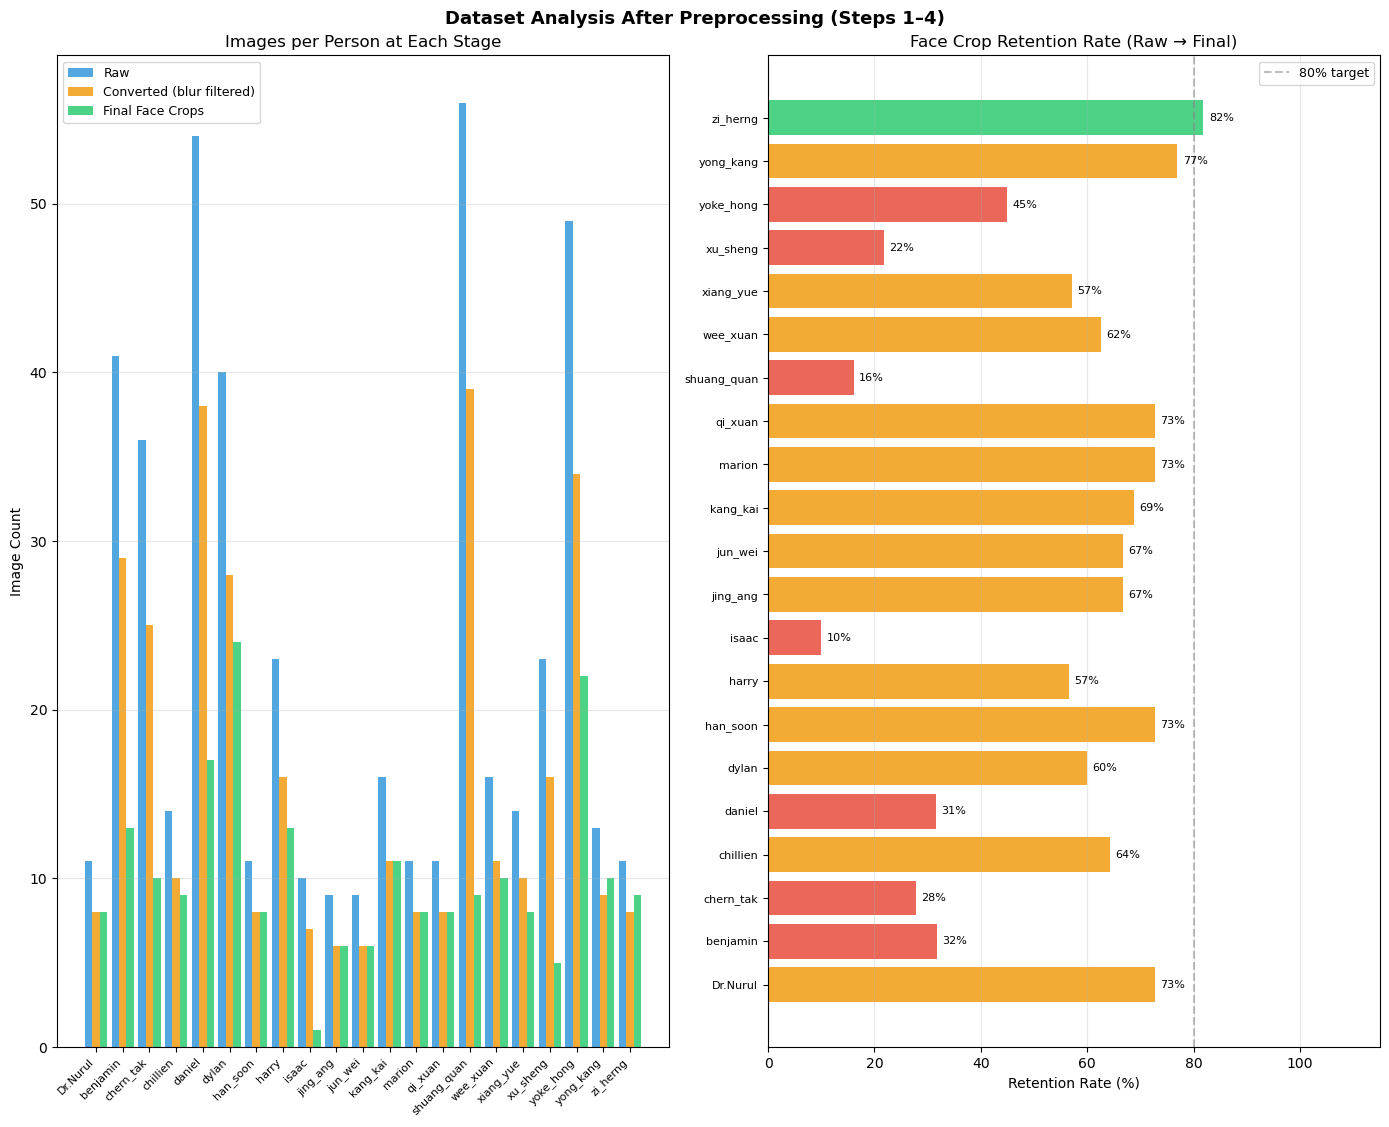


📋 SUMMARY:
  People:              21
  Raw images:          478
  Dropped (blurry):    143  (29.9%)
  After conversion:    335  (70.1%)
  Final face crops:    215  (45.0% overall retention)

  ❌ Low retention (<50%). Check: lighting, face angles, or lower BLUR_THRESHOLD.


In [27]:
def analyze_preprocessed_dataset():
    """
    Compare per-person image counts at each pipeline stage:
    Raw → Converted (blur filtered) → Final Processed (face crops).
    Shows retention rates and flags people with low retention.
    """
    print("📊 DATASET ANALYSIS AFTER PREPROCESSING")
    print("=" * 60)

    def count_per_person(folder, extensions=None):
        if extensions is None:
            extensions = {'.jpg', '.jpeg', '.png'}
        result = {}
        if not os.path.exists(folder):
            return result
        for person in sorted(os.listdir(folder)):
            person_path = os.path.join(folder, person)
            if os.path.isdir(person_path):
                files = [f for f in os.listdir(person_path)
                         if Path(f).suffix.lower() in extensions]
                result[person] = len(files)
        return result

    raw_counts   = count_per_person(RAW_FOLDER, {'.jpg', '.jpeg', '.png', '.heic'})
    conv_counts  = count_per_person(CONVERTED_FOLDER)
    final_counts = count_per_person(FINAL_PROCESSED_FOLDER)

    all_people = sorted(set(raw_counts) | set(conv_counts) | set(final_counts))

    if not all_people:
        print("❌ No data found. Run the pipeline (Steps 1–4) first.")
        return

    # --- Table ---
    print(f"\n  {'Person':<16} {'Raw':>5} {'Converted':>10} {'Final':>7} {'Retention':>10}")
    print("  " + "─" * 54)

    for person in all_people:
        raw   = raw_counts.get(person, 0)
        conv  = conv_counts.get(person, 0)
        final = final_counts.get(person, 0)
        ret   = f"{final / raw * 100:.0f}%" if raw > 0 else "—"
        flag  = (" ✅" if final / max(raw, 1) >= 0.8
                 else (" ⚠️" if final / max(raw, 1) >= 0.5 else " ❌"))
        print(f"  {person:<16} {raw:>5} {conv:>10} {final:>7} {ret:>10}{flag}")

    print("  " + "─" * 54)
    total_raw   = sum(raw_counts.values())
    total_conv  = sum(conv_counts.values())
    total_final = sum(final_counts.values())
    total_ret   = f"{total_final / total_raw * 100:.0f}%" if total_raw > 0 else "—"
    print(f"  {'TOTAL':<16} {total_raw:>5} {total_conv:>10} {total_final:>7} {total_ret:>10}")

    # --- Visualization ---
    fig, axes = plt.subplots(1, 2, figsize=(14, max(5, len(all_people) * 0.45 + 2)))
    fig.suptitle("Dataset Analysis After Preprocessing (Steps 1–4)",
                 fontsize=13, fontweight='bold')

    short = [p[:12] for p in all_people]
    x = range(len(all_people))
    w = 0.28

    # Chart 1: grouped bars — raw / converted / final per person
    axes[0].bar([i - w for i in x], [raw_counts.get(p, 0) for p in all_people],
                width=w, label='Raw', color='#3498db', alpha=0.85)
    axes[0].bar(list(x), [conv_counts.get(p, 0) for p in all_people],
                width=w, label='Converted (blur filtered)', color='#f39c12', alpha=0.85)
    axes[0].bar([i + w for i in x], [final_counts.get(p, 0) for p in all_people],
                width=w, label='Final Face Crops', color='#2ecc71', alpha=0.85)
    axes[0].set_xticks(list(x))
    axes[0].set_xticklabels(short, rotation=45, ha='right', fontsize=8)
    axes[0].set_ylabel("Image Count")
    axes[0].set_title("Images per Person at Each Stage")
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3, axis='y')

    # Chart 2: retention rate (raw → final face crops)
    retention  = [(final_counts.get(p, 0) / max(raw_counts.get(p, 1), 1)) * 100
                  for p in all_people]
    bar_colors = ['#2ecc71' if r >= 80 else ('#f39c12' if r >= 50 else '#e74c3c')
                  for r in retention]
    axes[1].barh(list(x), retention, color=bar_colors, alpha=0.85)
    axes[1].set_yticks(list(x))
    axes[1].set_yticklabels(short, fontsize=8)
    axes[1].axvline(x=80, color='gray', linestyle='--', alpha=0.5, label='80% target')
    axes[1].set_xlabel("Retention Rate (%)")
    axes[1].set_title("Face Crop Retention Rate (Raw → Final)")
    axes[1].set_xlim(0, 115)
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3, axis='x')
    for i, r in enumerate(retention):
        axes[1].text(r + 1, i, f'{r:.0f}%', va='center', fontsize=8)

    plt.tight_layout()
    plt.show()

    # --- Summary ---
    print(f"\n📋 SUMMARY:")
    print(f"  People:              {len(all_people)}")
    print(f"  Raw images:          {total_raw}")
    if total_raw > 0:
        blurry_dropped = total_raw - total_conv
        print(f"  Dropped (blurry):    {blurry_dropped}  ({blurry_dropped / total_raw * 100:.1f}%)")
        print(f"  After conversion:    {total_conv}  ({total_conv / total_raw * 100:.1f}%)")
        print(f"  Final face crops:    {total_final}  ({total_final / total_raw * 100:.1f}% overall retention)")

        overall_ret = total_final / total_raw
        if overall_ret < 0.5:
            print(f"\n  ❌ Low retention (<50%). Check: lighting, face angles, or lower BLUR_THRESHOLD.")
        elif overall_ret < 0.8:
            print(f"\n  ⚠️ Moderate retention. Some images had undetectable faces or were blurry.")
        else:
            print(f"\n  ✅ Good retention rate. Pipeline is working well.")

# Analyze dataset after completing Steps 1–4
analyze_preprocessed_dataset()


# 📊 Processing Summary & Statistics

View the complete processing statistics:

In [28]:
def generate_processing_summary():
    """Generate comprehensive processing summary across all pipeline stages."""
    
    print("📊 COMPLETE PROCESSING SUMMARY")
    print("=" * 60)
    
    # count images in a folder
    def count_folder_images(folder_path):
        if not os.path.exists(folder_path):
            return 0, 0  # (people_count, image_count)
        person_dirs = [d for d in os.listdir(folder_path) 
                      if os.path.isdir(os.path.join(folder_path, d))]
        total_files = 0
        for person in person_dirs:
            person_path = os.path.join(folder_path, person)
            files = [f for f in os.listdir(person_path) 
                    if Path(f).suffix.lower() in {'.jpg', '.jpeg', '.png'}]
            total_files += len(files)
        return len(person_dirs), total_files
    
    # Original raw dataset
    raw_people, raw_total = count_folder_images(RAW_FOLDER)
    print(f"\n📷 RAW DATASET:")
    print(f"  • People: {raw_people}")
    print(f"  • Images: {raw_total}")
    if raw_people > 0:
        print(f"  • Avg per person: {raw_total / raw_people:.1f}")
    
    # Processing stages
    stages = [
        ("CONVERTED",       CONVERTED_FOLDER,       None),
        ("PREPROCESSED",    PREPROCESSED_FOLDER,    None),
        ("FACES DETECTED",  FACES_DETECTED_FOLDER,  "detection"),
        ("FINAL PROCESSED", FINAL_PROCESSED_FOLDER, None),
        ("TEST PROCESSED",  TEST_PROCESSED_FOLDER,  "test"),
        ("AUGMENTED",       AUGMENTED_FOLDER,       "augmentation"),
    ]
    
    for stage_name, folder_path, stage_type in stages:
        people_count, file_count = count_folder_images(folder_path)
        
        if os.path.exists(folder_path):
            print(f"\n{stage_name}:")
            print(f"  • People: {people_count}")
            print(f"  • Images: {file_count}")
            
            if stage_type == "augmentation" and raw_total > 0 and file_count > 0:
                multiplication = file_count / raw_total
                print(f"  • Dataset multiplication: {multiplication:.1f}x")
                if people_count > 0:
                    print(f"  • Avg per person: {file_count / people_count:.1f}")
            
            if stage_type == "detection" and raw_total > 0 and file_count > 0:
                print(f"  • Faces per original: {file_count / raw_total:.1f}")
        else:
            print(f"\n❌ {stage_name}: Folder not created yet")
    
    print(f"\n{'=' * 60}")
    print(f"✨ Summary complete!")

generate_processing_summary()

📊 COMPLETE PROCESSING SUMMARY

📷 RAW DATASET:
  • People: 21
  • Images: 173
  • Avg per person: 8.2

CONVERTED:
  • People: 21
  • Images: 335

PREPROCESSED:
  • People: 21
  • Images: 335

FACES DETECTED:
  • People: 21
  • Images: 215
  • Faces per original: 1.2

FINAL PROCESSED:
  • People: 21
  • Images: 215

TEST PROCESSED:
  • People: 21
  • Images: 94

AUGMENTED:
  • People: 21
  • Images: 0

✨ Summary complete!
